# Forecasting Model

Este notebook construye un modelo de forecasting para predecir la demanda diaria a nivel tienda-categoría.

A partir del análisis exploratorio se identificó que la demanda está influenciada por factores temporales, promociones, características estructurales de las tiendas y diferencias entre categorías. En esta etapa se construirá un dataset de modelado, se generarán variables predictivas y se evaluará el desempeño del modelo contra un baseline.

## Librerias

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

## Style

In [2]:
WALMART_BLUE    = '#0071CE'
WALMART_DKBLUE  = '#004C91'
WALMART_YELLOW  = '#FFC220'
WALMART_GREY    = '#9E9E9E'
WALMART_LGREY   = '#F5F5F5'
WALMART_DARK    = '#1A1A2E'

plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": WALMART_GREY,
    "axes.labelcolor": WALMART_DARK,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": WALMART_DARK,
    "ytick.color": WALMART_DARK,
    "font.size": 11
})

## Datos

In [3]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

transactions = pd.read_csv(ROOT / "data" / "raw" / "transactions.csv")
stores = pd.read_csv(ROOT / "data" / "raw" / "stores.csv")
calendar = pd.read_csv(ROOT / "data" / "raw" / "calendar.csv")

In [4]:
transactions["date"] = pd.to_datetime(transactions["date"])
calendar["date"] = pd.to_datetime(calendar["date"])

## 1. Construcción del dataset de modelado

El modelo se construirá a nivel date-store_id-category, manteniendo la misma granularidad observada en el archivo transaccional.  
Se integran variables de calendario y características de tienda, pero se excluyen variables que no estarían disponibles al momento de predecir la demanda futura, como montos vendidos, unidades vendidas, ticket promedio y replenishment_signal.


In [5]:
df_model = (
    transactions
    .merge(stores, on="store_id", how="left")
    .merge(calendar, on="date", how="left")
    .sort_values(["store_id", "category", "date"])
    .reset_index(drop=True)
)

In [6]:
df_model.shape

(203958, 35)

In [7]:
target = "total_transactions"

columns_to_keep = [
    "date",
    "store_id",
    "category",
    "total_transactions",
    "has_promotion",
    
    # Store features
    "store_format",
    "region",
    "size_sqm",
    "num_checkouts",
    "opening_year",
    "socioeconomic_level",
    
    # Calendar features
    "day_of_week",
    "week_of_year",
    "month",
    "year",
    "quarter",
    "season",
    "is_holiday",
    "is_payday",
    "is_weekend",
    "is_navidad_season",
    "is_buen_fin",
    "is_semana_santa"
]

In [8]:
df_model = df_model[columns_to_keep].copy()

In [9]:
df_model.head()

,date,store_id,category,total_transactions,has_promotion,store_format,region,size_sqm,num_checkouts,opening_year,...,month,year,quarter,season,is_holiday,is_payday,is_weekend,is_navidad_season,is_buen_fin,is_semana_santa
0,2023-01-01,STR_001,Abarrotes,833,0,Supercenter,Norte,11072,37,2020,...,1,2023,1,Invierno,True,False,True,True,False,False
1,2023-01-02,STR_001,Abarrotes,1298,0,Supercenter,Norte,11072,37,2020,...,1,2023,1,Invierno,False,False,False,True,False,False
2,2023-01-03,STR_001,Abarrotes,1614,0,Supercenter,Norte,11072,37,2020,...,1,2023,1,Invierno,False,False,False,True,False,False
3,2023-01-04,STR_001,Abarrotes,1726,0,Supercenter,Norte,11072,37,2020,...,1,2023,1,Invierno,False,False,False,True,False,False
4,2023-01-05,STR_001,Abarrotes,2159,1,Supercenter,Norte,11072,37,2020,...,1,2023,1,Invierno,False,False,False,True,False,False


In [10]:
df_model["store_age"] = df_model["year"] - df_model["opening_year"]

bool_cols = [
    "is_holiday",
    "is_payday",
    "is_weekend",
    "is_navidad_season",
    "is_buen_fin",
    "is_semana_santa"
]

for col in bool_cols:
    df_model[col] = df_model[col].astype(int)

df_model["has_promotion"] = df_model["has_promotion"].astype(int)

In [11]:
df_model.head()

,date,store_id,category,total_transactions,has_promotion,store_format,region,size_sqm,num_checkouts,opening_year,...,year,quarter,season,is_holiday,is_payday,is_weekend,is_navidad_season,is_buen_fin,is_semana_santa,store_age
0,2023-01-01,STR_001,Abarrotes,833,0,Supercenter,Norte,11072,37,2020,...,2023,1,Invierno,1,0,1,1,0,0,3
1,2023-01-02,STR_001,Abarrotes,1298,0,Supercenter,Norte,11072,37,2020,...,2023,1,Invierno,0,0,0,1,0,0,3
2,2023-01-03,STR_001,Abarrotes,1614,0,Supercenter,Norte,11072,37,2020,...,2023,1,Invierno,0,0,0,1,0,0,3
3,2023-01-04,STR_001,Abarrotes,1726,0,Supercenter,Norte,11072,37,2020,...,2023,1,Invierno,0,0,0,1,0,0,3
4,2023-01-05,STR_001,Abarrotes,2159,1,Supercenter,Norte,11072,37,2020,...,2023,1,Invierno,0,0,0,1,0,0,3


## 2. Ingeniería de variables históricas

Para convertir el problema en un modelo supervisado de forecasting, se generan variables rezagadas y ventanas móviles por cada serie tienda-categoría.  
Estas variables permiten que el modelo aprenda patrones recientes, comportamiento semanal y cambios de tendencia sin utilizar información futura.

In [12]:
group_cols = ["store_id", "category"]

lags = [1, 7, 14, 28]

for lag in lags:
    df_model[f"lag_{lag}"] = (
        df_model
        .groupby(group_cols)[target]
        .shift(lag)
    )

shifted_target = (
    df_model
    .groupby(group_cols)[target]
    .shift(1)
)

rolling_windows = [7, 14, 28]

for window in rolling_windows:
    df_model[f"rolling_mean_{window}"] = (
        shifted_target
        .groupby([df_model["store_id"], df_model["category"]])
        .rolling(window, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    
    df_model[f"rolling_std_{window}"] = (
        shifted_target
        .groupby([df_model["store_id"], df_model["category"]])
        .rolling(window, min_periods=2)
        .std()
        .reset_index(level=[0, 1], drop=True)
    )

df_model["trend_7_28"] = df_model["rolling_mean_7"] / df_model["rolling_mean_28"]

In [13]:
df_model.head()

,date,store_id,category,total_transactions,has_promotion,store_format,region,size_sqm,num_checkouts,opening_year,...,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28,trend_7_28
0,2023-01-01,STR_001,Abarrotes,833,0,Supercenter,Norte,11072,37,2020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,STR_001,Abarrotes,1298,0,Supercenter,Norte,11072,37,2020,...,NaN,NaN,NaN,833.000000,NaN,833.000000,NaN,833.000000,NaN,1.0
2,2023-01-03,STR_001,Abarrotes,1614,0,Supercenter,Norte,11072,37,2020,...,NaN,NaN,NaN,1065.500000,328.804653,1065.500000,328.804653,1065.500000,328.804653,1.0
3,2023-01-04,STR_001,Abarrotes,1726,0,Supercenter,Norte,11072,37,2020,...,NaN,NaN,NaN,1248.333333,392.861723,1248.333333,392.861723,1248.333333,392.861723,1.0
4,2023-01-05,STR_001,Abarrotes,2159,1,Supercenter,Norte,11072,37,2020,...,NaN,NaN,NaN,1367.750000,399.918638,1367.750000,399.918638,1367.750000,399.918638,1.0


In [14]:
feature_nulls = (
    df_model
    .isna()
    .sum()
    .sort_values(ascending=False)
)

feature_nulls[feature_nulls > 0]

lag_28             13440
lag_14              6720
lag_7               3360
rolling_std_28       960
rolling_std_14       960
rolling_std_7        960
lag_1                480
trend_7_28           480
rolling_mean_7       480
rolling_mean_14      480
rolling_mean_28      480
dtype: int64

In [15]:
rows_before = len(df_model)

lag_cols = [f"lag_{lag}" for lag in lags]
rolling_cols = [
    col for col in df_model.columns 
    if col.startswith("rolling_mean_") or col.startswith("rolling_std_")
]

required_history_cols = lag_cols + rolling_cols

df_model = df_model.dropna(subset=required_history_cols).copy()

std_cols = [col for col in df_model.columns if col.startswith("rolling_std_")]
df_model[std_cols] = df_model[std_cols].fillna(0)

df_model["trend_7_28"] = df_model["trend_7_28"].replace([np.inf, -np.inf], np.nan)
df_model["trend_7_28"] = df_model["trend_7_28"].fillna(1)

rows_after = len(df_model)

In [16]:

print(f"Rows before warmup removal: {rows_before:,}")
print(f"Rows after warmup removal: {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after:,}")
print(f"Percentage removed: {(rows_before - rows_after) / rows_before:.2%}")
print(f"Modeling first date: {df_model['date'].min().date()}")
print(f"Modeling last date: {df_model['date'].max().date()}")

Rows before warmup removal: 203,958
Rows after warmup removal: 190,518
Rows removed: 13,440
Percentage removed: 6.59%
Modeling first date: 2023-01-29
Modeling last date: 2024-02-29


In [17]:
print(df_model["date"].min())
print(df_model["date"].max())

2023-01-29 00:00:00
2024-02-29 00:00:00


## 3. División temporal

Dividiré cronológicamente en tres periodos:

- **Train:** enero 2023 – noviembre 2023
- **Validation:** diciembre 2023
- **Test:** enero 2024 – febrero 2024

Esta estrategia permite ajustar el modelo utilizando únicamente información disponible hasta cada momento y evaluar posteriormente su capacidad de generalizar hacia periodos futuros.

In [18]:
train_end = pd.Timestamp("2023-11-30")
valid_end = pd.Timestamp("2023-12-31")

train = df_model[df_model["date"] <= train_end].copy()

valid = df_model[
    (df_model["date"] > train_end) &
    (df_model["date"] <= valid_end)
].copy()

test = df_model[
    df_model["date"] > valid_end
].copy()

split_summary = pd.DataFrame({
    "Period": ["Train", "Validation", "Test"],
    "Start date": [
        train["date"].min().date(),
        valid["date"].min().date(),
        test["date"].min().date()
    ],
    "End date": [
        train["date"].max().date(),
        valid["date"].max().date(),
        test["date"].max().date()
    ],
    "Rows": [
        len(train),
        len(valid),
        len(test)
    ],
    "Unique stores": [
        train["store_id"].nunique(),
        valid["store_id"].nunique(),
        test["store_id"].nunique()
    ],
    "Unique categories": [
        train["category"].nunique(),
        valid["category"].nunique(),
        test["category"].nunique()
    ]
})

In [19]:
split_summary

,Period,Start date,End date,Rows,Unique stores,Unique categories
0,Train,2023-01-29,2023-11-30,146856,80,6
1,Validation,2023-12-01,2023-12-31,14880,80,6
2,Test,2024-01-01,2024-02-29,28782,80,6


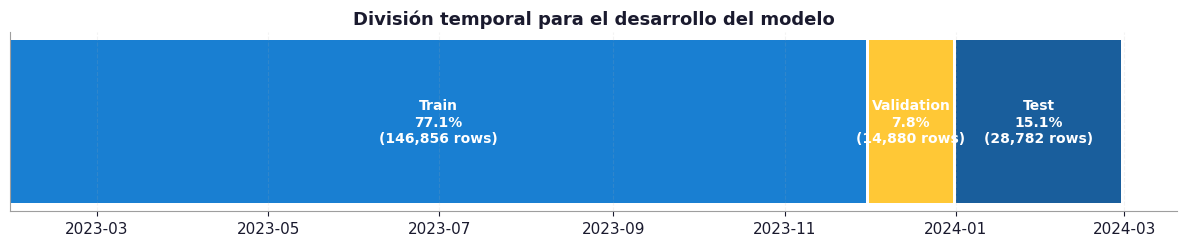

In [20]:
total_rows = len(df_model)

periods = [
    ("Train", train, WALMART_BLUE),
    ("Validation", valid, WALMART_YELLOW),
    ("Test", test, WALMART_DKBLUE),
]

fig, ax = plt.subplots(figsize=(12, 2.6))

for label, data, color in periods:

    start = data["date"].min()
    end = data["date"].max()

    pct = len(data) / total_rows * 100

    ax.barh(
        y=0,
        width=(end - start).days,
        left=start,
        height=0.45,
        color=color,
        alpha=0.9
    )

    center = start + (end - start) / 2

    ax.text(
        center,
        0,
        f"{label}\n{pct:.1f}%\n({len(data):,} rows)",
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "División temporal para el desarrollo del modelo",
    fontsize=13,
    fontweight="bold",
    color=WALMART_DARK
)

ax.set_yticks([])
ax.grid(axis="x", linestyle="--", alpha=0.15)

plt.tight_layout()
plt.show()

## 4. Modelo baseline


En problemas de demanda diaria, una estrategia sencilla consiste en asumir que el comportamiento del siguiente día será similar al observado una semana antes (`lag_7`). Este baseline aprovecha el patrón semanal identificado durante el análisis exploratorio y representa una referencia difícil de superar para muchos problemas de forecasting.

El objetivo del modelo final será demostrar una mejora consistente respecto a este enfoque base.

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [22]:
def evaluate_forecast(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = (
        np.abs((y_true - y_pred) / y_true)
    ).mean() * 100

    wape = (
        np.abs(y_true - y_pred).sum()
        /
        np.abs(y_true).sum()
    ) * 100

    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame({
        "MAE": [mae],
        "RMSE": [rmse],
        "MAPE (%)": [mape],
        "WAPE (%)": [wape],
        "R²": [r2]
    })

In [23]:
y_train = train[target]
y_valid = valid[target]
y_test = test[target]

In [24]:
baseline_pred_valid = valid["lag_7"]

baseline_results = evaluate_forecast(
    y_valid,
    baseline_pred_valid
)

baseline_results.index = ["Baseline (lag_7)"]

baseline_results.round(2)

,MAE,RMSE,MAPE (%),WAPE (%),R²
Baseline (lag_7),289.0,604.68,24.16,26.57,0.72


In [25]:
comparison = baseline_results.copy()
comparison.round(2)

,MAE,RMSE,MAPE (%),WAPE (%),R²
Baseline (lag_7),289.0,604.68,24.16,26.57,0.72


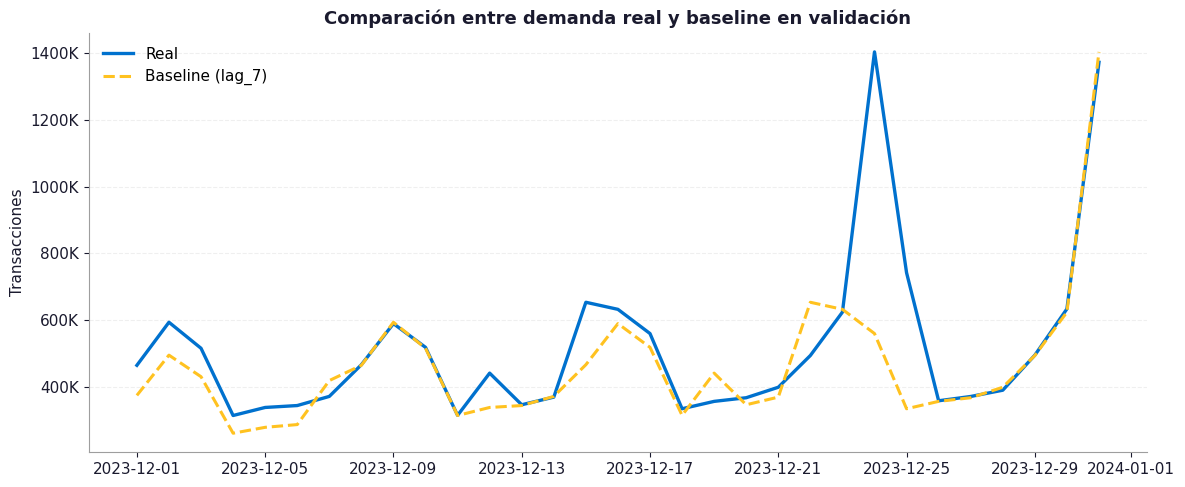

In [26]:
valid_plot = (
    valid
    .assign(pred_baseline=baseline_pred_valid)
    .groupby("date", as_index=False)
    .agg(
        real=("total_transactions", "sum"),
        baseline=("pred_baseline", "sum")
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    valid_plot["date"],
    valid_plot["real"],
    color=WALMART_BLUE,
    linewidth=2.4,
    label="Real"
)

ax.plot(
    valid_plot["date"],
    valid_plot["baseline"],
    color=WALMART_YELLOW,
    linewidth=2.2,
    linestyle="--",
    label="Baseline (lag_7)"
)

ax.set_title(
    "Comparación entre demanda real y baseline en validación",
    fontsize=13,
    fontweight="bold",
    color=WALMART_DARK
)

ax.set_xlabel("")
ax.set_ylabel("Transacciones")
ax.grid(axis="y", linestyle="--", alpha=0.20)
ax.legend(frameon=False)

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.tight_layout()
plt.show()

## 5. Preparación para el entrenamiento

Se definen las variables que serán utilizadas por los modelos y se separan las variables predictoras de la variable objetivo.

Las variables utilizadas corresponden únicamente a información disponible al momento de realizar la predicción, evitando cualquier fuga de información

In [27]:
target = "total_transactions"

categorical_features = [
    "store_id",
    "category",
    "store_format",
    "region",
    "socioeconomic_level",
    "season"
]

numerical_features = [
    "has_promotion",
    "size_sqm",
    "num_checkouts",
    "store_age",
    "day_of_week",
    "week_of_year",
    "month",
    "year",
    "quarter",
    "is_holiday",
    "is_payday",
    "is_weekend",
    "is_navidad_season",
    "is_buen_fin",
    "is_semana_santa",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_28",
    "trend_7_28"
]

features = categorical_features + numerical_features

In [28]:
X_train = train[features].copy()
X_valid = valid[features].copy()
X_test  = test[features].copy()

y_train = train[target]
y_valid = valid[target]
y_test  = test[target]

print(f"Train: {X_train.shape}")
print(f"Validation: {X_valid.shape}")
print(f"Test: {X_test.shape}")

Train: (146856, 32)
Validation: (14880, 32)
Test: (28782, 32)


## 6. Modelo 1 — Linear Regression

Como primer modelo supervisado se utiliza una regresión lineal. Aunque este tipo de modelo tiene capacidad limitada para capturar relaciones no lineales, sirve como una referencia adicional antes de utilizar modelos basados en árboles.

Para este modelo las variables categóricas se transforman mediante *One-Hot Encoding*.

In [29]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

In [30]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

linear_model = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['store_id', 'category',
                                                   'store_format', 'region',
                                                   'socioeconomic_level',
                                                   'season'])])),
                ('model', LinearRegression())])

In [31]:
linear_pred_valid = linear_model.predict(X_valid)

linear_results = evaluate_forecast(
    y_valid,
    linear_pred_valid
)

linear_results.index = ["Linear Regression"]

comparison = pd.concat([
    baseline_results,
    linear_results
])

comparison.round(2)

,MAE,RMSE,MAPE (%),WAPE (%),R²
Baseline (lag_7),289.00,604.68,24.16,26.57,0.72
Linear Regression,355.24,626.62,49.66,32.66,0.70


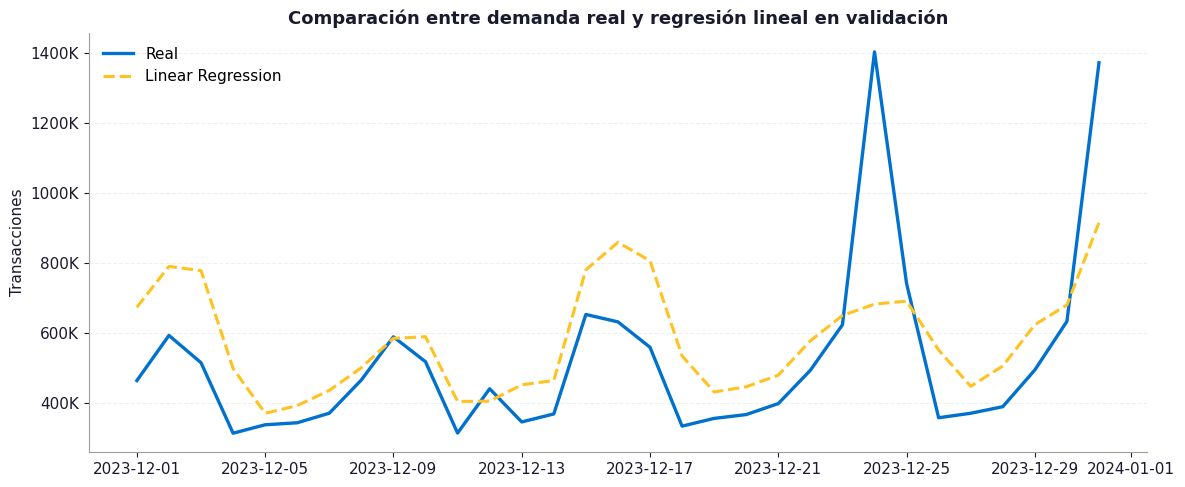

In [32]:
valid_plot_lr = (
    valid
    .assign(pred_linear=linear_pred_valid)
    .groupby("date", as_index=False)
    .agg(
        real=("total_transactions", "sum"),
        linear=("pred_linear", "sum")
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    valid_plot_lr["date"],
    valid_plot_lr["real"],
    color=WALMART_BLUE,
    linewidth=2.4,
    label="Real"
)

ax.plot(
    valid_plot_lr["date"],
    valid_plot_lr["linear"],
    color=WALMART_YELLOW,
    linewidth=2.2,
    linestyle="--",
    label="Linear Regression"
)

ax.set_title(
    "Comparación entre demanda real y regresión lineal en validación",
    fontsize=13,
    fontweight="bold",
    color=WALMART_DARK
)

ax.set_xlabel("")
ax.set_ylabel("Transacciones")
ax.grid(axis="y", linestyle="--", alpha=0.20)
ax.legend(frameon=False)

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.tight_layout()
plt.show()

La regresión lineal no logró superar al baseline construido a partir de lag_7. Aunque incorpora información adicional sobre promociones, calendario y características de las tiendas, su naturaleza lineal limita su capacidad para capturar interacciones complejas y cambios abruptos en la demanda. En particular, el modelo tiende a suavizar los picos observados durante eventos comerciales, lo que sugiere la necesidad de utilizar modelos capaces de aprender relaciones no lineales.

## 7. Modelo final — LightGBM

El análisis exploratorio mostró que la demanda depende de relaciones no lineales entre promociones, eventos comerciales, formato de tienda, región y comportamiento histórico.

Dado que la regresión lineal no logró superar al baseline, se selecciona LightGBM como modelo final por su capacidad para modelar interacciones complejas, variables categóricas y efectos no lineales sin requerir transformaciones adicionales.

In [33]:
import lightgbm as lgb

In [34]:
for col in categorical_features:
    X_train[col] = X_train[col].astype("category")
    X_valid[col] = X_valid[col].astype("category")
    X_test[col] = X_test[col].astype("category")

In [35]:
lgb_model = lgb.LGBMRegressor(

    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [36]:
lgb_model.fit(

    X_train,

    y_train,

    eval_set=[

        (X_train, y_train),

        (X_valid, y_valid)

    ],

    eval_metric="l1",

    callbacks=[

        lgb.early_stopping(50),

        lgb.log_evaluation(50)

    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004447 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3118
[LightGBM] [Info] Number of data points in the train set: 146856, number of used features: 30
[LightGBM] [Info] Start training from score 599.854048
Training until validation scores don't improve for 50 rounds
[50]	training's l1: 98.1422	training's l2: 25661.7	valid_1's l1: 273.763	valid_1's l2: 426976
[100]	training's l1: 83.0546	training's l2: 18971	valid_1's l1: 255.805	valid_1's l2: 369257
Early stopping, best iteration is:
[96]	training's l1: 83.5254	training's l2: 19187.2	valid_1's l1: 255.505	valid_1's l2: 368350


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              objective='regression', random_state=42, subsample=0.8)

In [37]:
lgb_pred = lgb_model.predict(X_valid)

lgb_results = evaluate_forecast(

    y_valid,

    lgb_pred

)

lgb_results.index = ["LightGBM"]

comparison = pd.concat([

    comparison,

    lgb_results

])

comparison.round(2)

,MAE,RMSE,MAPE (%),WAPE (%),R²
Baseline (lag_7),289.00,604.68,24.16,26.57,0.72
Linear Regression,355.24,626.62,49.66,32.66,0.70
LightGBM,255.51,606.92,19.64,23.49,0.72


In [38]:
valid_plot_lgb = (
    valid
    .assign(pred=lgb_pred)
    .groupby("date", as_index=False)
    .agg(
        real=("total_transactions","sum"),
        pred=("pred","sum")
    )
)

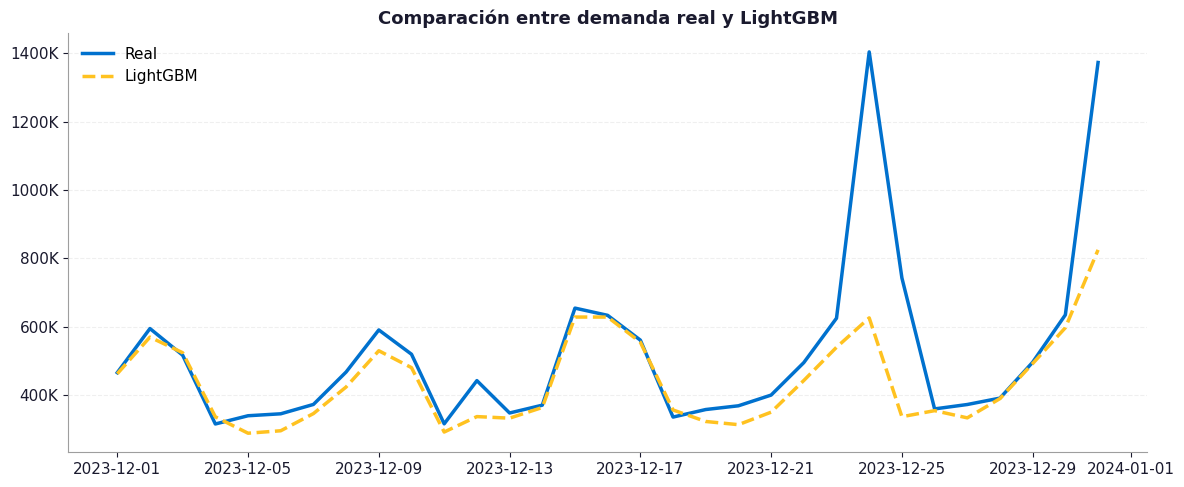

In [39]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(

    valid_plot_lgb["date"],
    valid_plot_lgb["real"],
    color=WALMART_BLUE,
    linewidth=2.5,
    label="Real"

)

ax.plot(

    valid_plot_lgb["date"],
    valid_plot_lgb["pred"],
    color=WALMART_YELLOW,
    linewidth=2.5,
    linestyle="--",
    label="LightGBM"

)

ax.set_title(

    "Comparación entre demanda real y LightGBM",
    fontsize=13,
    fontweight="bold",
    color=WALMART_DARK

)

ax.grid(axis="y", linestyle="--", alpha=0.20)

ax.legend(frameon=False)

ax.yaxis.set_major_formatter(

    mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K")

)

plt.tight_layout()

plt.show()

In [42]:
print(len(train))
print(len(valid))
print(len(test))

print(train["date"].min(), train["date"].max())
print(valid["date"].min(), valid["date"].max())
print(test["date"].min(), test["date"].max())

146856
14880
28782
2023-01-29 00:00:00 2023-11-30 00:00:00
2023-12-01 00:00:00 2023-12-31 00:00:00
2024-01-01 00:00:00 2024-02-29 00:00:00


In [43]:
lgb_results

,MAE,RMSE,MAPE (%),WAPE (%),R²
LightGBM,255.505346,606.918726,19.641991,23.488259,0.719213


In [44]:
feature_importance = (
    pd.DataFrame({
        "Feature": features,
        "Importance": lgb_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

feature_importance.head(20)

,Feature,Importance
6,has_promotion,330
16,is_payday,314
27,rolling_mean_28,303
10,day_of_week,258
11,week_of_year,216
19,is_buen_fin,190
15,is_holiday,167
23,lag_14,159
22,lag_7,152
24,lag_28,148


La importancia de variables obtenida mediante LightGBM es consistente con los hallazgos del análisis exploratorio. Las promociones, los días de pago, la estacionalidad semanal y los eventos comerciales aparecen entre los predictores más relevantes, confirmando que la demanda responde principalmente a factores temporales y comerciales. Asimismo, variables estructurales como la región presentan una importancia relativamente baja, lo que coincide con el análisis exploratorio donde las diferencias regionales disminuían al controlar por el formato de tienda.

In [41]:
# Evaluación del modelo LightGBM original sobre el conjunto de test
lgb_pred_test = lgb_model.predict(X_test)

res_v1_test = evaluate_forecast(
    y_test,
    lgb_pred_test
)

res_v1_test.index = ["LightGBM v1 (original)"]

res_v1_test[["MAE", "RMSE", "MAPE (%)", "WAPE (%)", "R²"]].round(2)

,MAE,RMSE,MAPE (%),WAPE (%),R²
LightGBM v1 (original),156.75,255.64,40.54,30.61,0.67


## 7.1 Refinamiento del esquema de validación

Durante la evaluación del modelo se identificó que el primer esquema de partición temporal, aunque respetaba el orden cronológico, obligaba al modelo a predecir enero de 2024 con poca referencia del comportamiento de enero del año anterior debido al periodo de calentamiento requerido por las variables históricas.

En problemas de forecasting, el esquema de validación forma parte central del diseño del modelo. Por ello, antes de agregar nuevas variables o incrementar la complejidad del algoritmo, se replantea la división temporal para que el entrenamiento cubra un ciclo anual completo.

La nueva partición queda definida como:

- **Train:** enero 2023 – diciembre 2023
- **Validación:** enero 2024
- **Test:** febrero 2024

Este ajuste permite evaluar el modelo en un escenario más representativo, manteniendo el orden temporal y evitando fuga de información.

In [51]:
train_refined = df_model[df_model["date"] <= pd.Timestamp("2023-12-31")].copy()

valid_refined = df_model[
    (df_model["date"] > pd.Timestamp("2023-12-31")) &
    (df_model["date"] <= pd.Timestamp("2024-01-31"))
].copy()

test_refined = df_model[df_model["date"] > pd.Timestamp("2024-01-31")].copy()

split_refined = pd.DataFrame({
    "Period": ["Train", "Validation", "Test"],
    "Start date": [
        train_refined["date"].min().date(),
        valid_refined["date"].min().date(),
        test_refined["date"].min().date()
    ],
    "End date": [
        train_refined["date"].max().date(),
        valid_refined["date"].max().date(),
        test_refined["date"].max().date()
    ],
    "Rows": [
        len(train_refined),
        len(valid_refined),
        len(test_refined)
    ],
    "Unique days": [
        train_refined["date"].nunique(),
        valid_refined["date"].nunique(),
        test_refined["date"].nunique()
    ]
})

split_refined

,Period,Start date,End date,Rows,Unique days
0,Train,2023-01-29,2023-12-31,161736,337
1,Validation,2024-01-01,2024-01-31,14880,31
2,Test,2024-02-01,2024-02-29,13902,29


In [52]:
X_train_refined = train_refined[features].copy()
X_valid_refined = valid_refined[features].copy()
X_test_refined  = test_refined[features].copy()

y_train_refined = train_refined[target]
y_valid_refined = valid_refined[target]
y_test_refined  = test_refined[target]

for col in categorical_features:
    X_train_refined[col] = X_train_refined[col].astype("category")
    X_valid_refined[col] = X_valid_refined[col].astype("category")
    X_test_refined[col]  = X_test_refined[col].astype("category")

In [53]:
lgb_refined = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_refined.fit(
    X_train_refined,
    y_train_refined,
    eval_set=[
        (X_train_refined, y_train_refined),
        (X_valid_refined, y_valid_refined)
    ],
    eval_metric="l1",
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006621 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3125
[LightGBM] [Info] Number of data points in the train set: 161736, number of used features: 31
[LightGBM] [Info] Start training from score 644.745969
Training until validation scores don't improve for 50 rounds
[50]	training's l1: 107.982	training's l2: 33065	valid_1's l1: 239.731	valid_1's l2: 149400
Early stopping, best iteration is:
[17]	training's l1: 215.638	training's l2: 119518	valid_1's l1: 248.157	valid_1's l2: 105304


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              objective='regression', random_state=42, subsample=0.8)

In [54]:
lgb_pred_refined_test = lgb_refined.predict(X_test_refined)

refined_results = evaluate_forecast(
    y_test_refined,
    lgb_pred_refined_test
)

refined_results.index = ["LightGBM — split refinado"]

comparison_refinement = pd.concat([
    res_v1_test.rename(index={"LightGBM v1 (original)": "LightGBM — split original"}),
    refined_results
])

comparison_refinement[["MAE", "RMSE", "MAPE (%)", "WAPE (%)", "R²"]].round(2)

,MAE,RMSE,MAPE (%),WAPE (%),R²
LightGBM — split original,156.75,255.64,40.54,30.61,0.67
LightGBM — split refinado,186.93,241.71,79.25,35.47,0.72


Se evaluó un segundo esquema de partición temporal para analizar la sensibilidad del modelo al diseño experimental. Si bien este esquema incrementó el R², también aumentó el error absoluto (MAE y WAPE), por lo que se decidió conservar el split original como modelo final. Este resultado evidencia que en forecasting la selección del esquema de validación puede modificar significativamente las métricas y que ninguna métrica aislada debe utilizarse para seleccionar un modelo

Idealmente, el modelo debería entrenarse con múltiples años de información para observar varias ocurrencias de eventos estacionales como Buen Fin, Navidad o Semana Santa. Contar con un único ciclo anual limita la capacidad de estimar variaciones interanuales y obliga a que el diseño del esquema de validación sea especialmente cuidadoso.

## 8. Interpretación del modelo

Además de evaluar el desempeño predictivo, es importante interpretar el comportamiento del modelo y verificar que los patrones aprendidos sean consistentes con el análisis exploratorio.

La importancia de variables permite validar que el modelo está utilizando información relevante para explicar la demanda y que las relaciones identificadas durante el EDA efectivamente contribuyen a la capacidad predictiva del modelo.

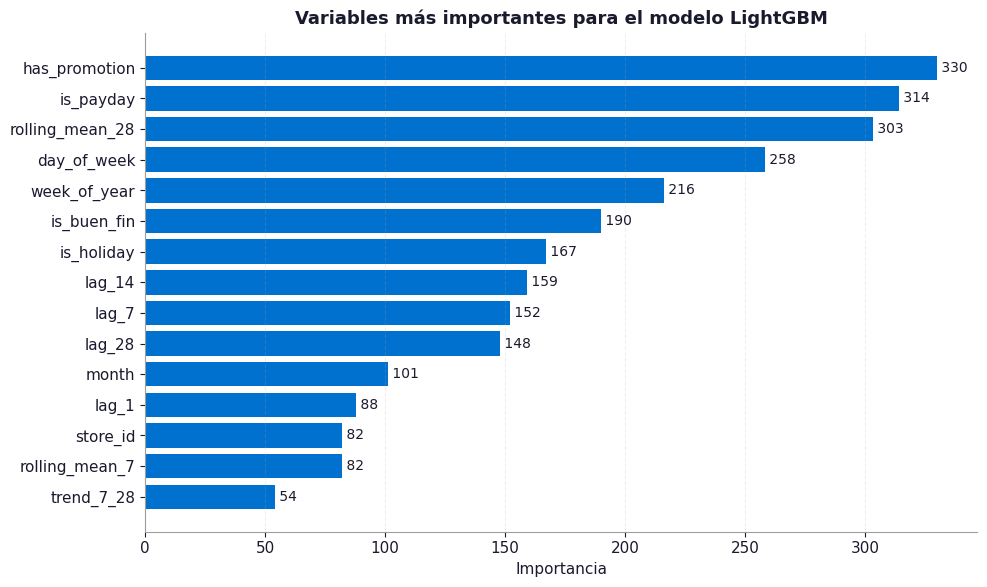

In [55]:
feature_importance = (
    pd.DataFrame({
        "Feature": features,
        "Importance": lgb_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

top_features = feature_importance.head(15).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_features["Feature"],
    top_features["Importance"],
    color=WALMART_BLUE
)

ax.set_title(
    "Variables más importantes para el modelo LightGBM",
    fontsize=13,
    fontweight="bold",
    color=WALMART_DARK
)

ax.set_xlabel("Importancia")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.20)

for bar in bars:
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {bar.get_width():.0f}",
        va="center",
        fontsize=10,
        color=WALMART_DARK
    )

plt.tight_layout()
plt.show()

La importancia de variables es consistente con los hallazgos del análisis exploratorio. El modelo asigna alta relevancia a promociones (`has_promotion`), días de pago (`is_payday`), comportamiento histórico (`rolling_mean_28`, `lag_7`, `lag_14`, `lag_28`) y variables temporales (`day_of_week`, `week_of_year`, `is_buen_fin`).

Esto confirma que el modelo está capturando los principales factores operativos y temporales asociados a la demanda. Además, variables como `region` no aparecen entre las más relevantes, lo que coincide con el análisis previo donde las diferencias regionales se explicaban parcialmente por la composición de formatos de tienda.

## 9. Evaluación final en test

Una vez seleccionado LightGBM como modelo final con base en el conjunto de validación, se evalúa su desempeño sobre el conjunto de test.

El conjunto de test corresponde a enero y febrero de 2024, periodo que no fue utilizado para entrenar ni comparar modelos. Esta evaluación representa una aproximación más realista al desempeño esperado del modelo en datos futuros.

In [56]:
lgb_pred_test = lgb_model.predict(X_test)

test_results = evaluate_forecast(
    y_test,
    lgb_pred_test
)

test_results.index = ["LightGBM - Test"]

test_results[["MAE", "RMSE", "WAPE (%)", "R²"]].round(2)

,MAE,RMSE,WAPE (%),R²
LightGBM - Test,156.75,255.64,30.61,0.67


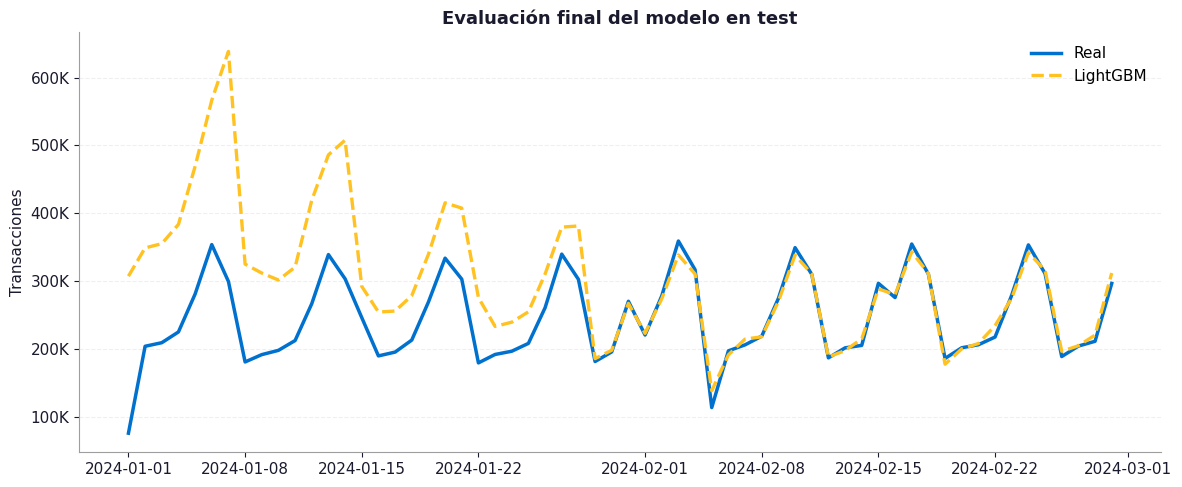

In [57]:
test_plot = (
    test
    .assign(pred=lgb_pred_test)
    .groupby("date", as_index=False)
    .agg(
        real=("total_transactions", "sum"),
        pred=("pred", "sum")
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    test_plot["date"],
    test_plot["real"],
    color=WALMART_BLUE,
    linewidth=2.5,
    label="Real"
)

ax.plot(
    test_plot["date"],
    test_plot["pred"],
    color=WALMART_YELLOW,
    linewidth=2.4,
    linestyle="--",
    label="LightGBM"
)

ax.set_title(
    "Evaluación final del modelo en test",
    fontsize=13,
    fontweight="bold",
    color=WALMART_DARK
)

ax.set_xlabel("")
ax.set_ylabel("Transacciones")
ax.grid(axis="y", linestyle="--", alpha=0.20)
ax.legend(frameon=False)

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.tight_layout()
plt.show()

## 10. Implicaciones para el negocio


El análisis exploratorio permitió identificar los principales factores asociados a la demanda, entre ellos promociones, eventos comerciales, estacionalidad semanal y características propias de las tiendas. Estos hallazgos guiaron la construcción de variables predictivas que posteriormente fueron confirmadas por la importancia de variables del modelo LightGBM.

Frente a los modelos de referencia, LightGBM obtuvo el mejor desempeño durante la validación y mantuvo una capacidad de generalización consistente sobre datos no observados. Esto demuestra que incorporar información temporal y contextual permite anticipar la demanda con mayor precisión que utilizar únicamente el comportamiento histórico reciente.

Desde una perspectiva de negocio, el modelo puede utilizarse como una herramienta de apoyo para la planeación de inventario, asignación de personal y preparación de eventos comerciales. Asimismo, representa una alternativa para anticipar la demanda futura y complementar señales operativas como replenishment_signal, que en este proyecto se excluyó deliberadamente para evitar dependencia de información generada por otros procesos del negocio.

## 11. Ejemplo de uso operativo del forecast

Para aterrizar el valor del modelo, se construye un ejemplo simple de cómo las predicciones podrían utilizarse para priorizar acciones operativas.

La idea no es automatizar directamente una decisión de inventario, sino mostrar cómo el forecast puede convertirse en una señal accionable para equipos de tienda, abastecimiento o planeación comercial.

In [58]:
# Construcción de una tabla de oportunidades

test_actions = test.copy()

test_actions["predicted_transactions"] = lgb_pred_test

test_actions["expected_increase"] = (
    test_actions["predicted_transactions"] -
    test_actions["lag_7"]
)

test_actions["expected_lift_pct"] = (
    test_actions["expected_increase"] /
    test_actions["lag_7"]
) * 100

priority_cases = (
    test_actions[
        (test_actions["expected_lift_pct"] > 25) &
        (
            test_actions["predicted_transactions"] >
            test_actions["predicted_transactions"].quantile(0.75)
        )
    ]
    .sort_values(
        "expected_lift_pct",
        ascending=False
    )
    [[
        "date",
        "store_id",
        "category",
        "store_format",
        "region",
        "has_promotion",
        "lag_7",
        "predicted_transactions",
        "expected_increase",
        "expected_lift_pct"
    ]]
    .head(10)
)

priority_cases = priority_cases.rename(columns={
    "lag_7": "transactions_last_week",
    "predicted_transactions": "forecast_transactions",
    "expected_increase": "expected_increase",
    "expected_lift_pct": "expected_growth_pct"
})

priority_cases.round(2)

,date,store_id,category,store_format,region,has_promotion,transactions_last_week,forecast_transactions,expected_increase,expected_growth_pct
153767,2024-01-08,STR_061,Bebidas,Express,Occidente,1,120.0,979.24,859.24,716.04
52222,2024-01-08,STR_021,Cuidado_Personal,Bodega,Norte,0,109.0,854.19,745.19,683.66
138904,2024-01-08,STR_055,Cuidado_Personal,Bodega,Norte,1,126.0,924.83,798.83,633.99
138482,2024-01-08,STR_055,Bebidas,Bodega,Norte,0,145.0,1010.88,865.88,597.16
60722,2024-01-08,STR_024,Hogar,Bodega,Centro,1,136.0,943.98,807.98,594.10
43297,2024-01-08,STR_017,Ropa,Supercenter,Occidente,1,146.0,973.50,827.50,566.78
17372,2024-01-08,STR_007,Hogar,Supercenter,Sur,1,176.0,1160.36,984.36,559.30
9722,2024-01-08,STR_004,Hogar,Supercenter,Oriente,1,187.0,1197.24,1010.24,540.23
130835,2024-01-08,STR_052,Bebidas,Bodega,Oriente,1,187.0,1188.48,1001.48,535.55
146117,2024-01-08,STR_058,Bebidas,Express,Centro,1,143.0,870.87,727.87,509.00


### ¿Cómo interpretar esta tabla?

Cada fila representa una combinación **tienda–categoría–fecha** donde el modelo anticipa un incremento importante en la demanda respecto al comportamiento observado una semana antes.

Las columnas se interpretan de la siguiente manera:

- **date:** día para el cual se realiza la predicción.
- **store_id:** tienda donde se espera el incremento de demanda.
- **category:** categoría de productos involucrada.
- **has_promotion:** indica si existe una promoción activa ese día.
- **transactions_last_week:** transacciones registradas exactamente una semana antes.
- **forecast_transactions:** demanda estimada por el modelo.
- **expected_increase:** incremento absoluto esperado respecto a la semana anterior.
- **expected_growth_pct:** incremento porcentual esperado respecto a la semana anterior.

El objetivo no es únicamente conocer cuántas transacciones ocurrirán, sino identificar dónde se espera el mayor incremento de demanda para priorizar acciones operativas.

### Ejemplo de interpretación

Supongamos que el modelo estima para la tienda **STR_061**, categoría **Bebidas**, aproximadamente **979 transacciones** para el **8 de enero**, mientras que una semana antes se registraron únicamente **120 transacciones**.

Esto representa un incremento esperado cercano a **859 transacciones (+716%)** respecto a la semana anterior.

Aunque el porcentaje es elevado debido a que la referencia corresponde a los días posteriores al cierre de la temporada navideña, el modelo está indicando que esa tienda recuperará un volumen considerable de demanda y, por lo tanto, conviene prepararse con anticipación.

### Posibles acciones de negocio

Este tipo de predicciones puede utilizarse para apoyar decisiones como:

| Situación detectada por el modelo | Acción sugerida |
|----------------------------------|-----------------|
| Incremento importante en una categoría | Incrementar inventario preventivamente antes del día pronosticado. |
| Alta demanda con promoción activa | Verificar disponibilidad de productos promocionales y evitar quiebres de stock. |
| Incremento simultáneo en varias categorías | Reforzar personal operativo y abrir más cajas durante los periodos de mayor demanda. |
| Caída esperada de demanda | Ajustar pedidos o redistribuir inventario hacia otras tiendas. |
| Incrementos recurrentes en una tienda | Revisar capacidad operativa y planear abastecimiento de largo plazo. |

De esta forma, el modelo deja de ser únicamente una herramienta de predicción y se convierte en un mecanismo de apoyo para la toma de decisiones operativas.